# Lakeside heating DSM — PyTorch dual-head tutorial

> **DO NOT RELEASE FOR OPERATIONAL DSM.** Honesty stamp: **`HYBRID_SCREENING`**.

Trains **ResMLP dual-head** (optional GRU in full mode) on the **real BAS 15-min store only**.
Does **not** train deltas and **never** overwrites the sklearn hybrid desktop champion.

| | |
|---|---|
| Data | `REAL_BAS_15MIN` only |
| Artifact stem | `real_baseline_15min_torch_v1` |
| Splits | Shared `chrono_splits` → `eval/split_manifest.json` |
| Lean default | `LEAN=True`: 1 seed, ResMLP only, `MAX_DAYS=36` |
| Full tutorial | 5 seeds `{11,22,33,44,55}` + `gru_dualhead` |

CLI mirror: `scripts/run_torch_tutorial_train.py --lean`.


## 1 · Title & multi-output problem

We predict **seven simultaneous outputs** every 15 minutes for one K-12 school day
(96 steps from midnight):

| Index | Target | Unit | Role |
|---|---|---|---|
| 0 | `facility_kw` | kW | Whole-building electric demand (DSM / cost) |
| 1–6 | `zone_temp_*_f` | °F | Six thermal-area air temperatures (comfort) |

Canonical order is locked in `TARGET_COLS` — never reorder heads or ONNX outputs.

```text
 midnight state + future OAT/control
              │
              ▼
        ┌─────────────┐
        │  Surrogate  │
        │   model     │
        └──────┬──────┘
               │
       ┌───────┴────────┐
       ▼                ▼
  96 × facility_kw   96 × 6 zone temps °F
```

```mermaid
flowchart TD
  Midnight["Midnight state + future exogenous/control"] --> Model["Surrogate model"]
  Model --> Kw["96 x facility_kw"]
  Model --> Zones["96 x 6 zone_temp_*_f"]
```

> **Honesty:** ship claim is **`HYBRID_SCREENING` only**.  
> **DO NOT RELEASE FOR OPERATIONAL DSM.**


## 2 · Predictands (what success looks like)

- **Demand fidelity:** morning-peak (HE 05–09) facility MAE/RMSE in **kW**, plus daily peak magnitude/timing and daily kWh error.
- **Comfort fidelity:** per-zone MAE in **°F** — always show the **worst zone**, never hide it behind a mean.
- Metrics live in `metrics_report` (MAE, RMSE, CV(RMSE), NMBE, horizons). Do not invent numbers in Markdown.


## 3 · Multi-output time-series framing

Each row is one 15-min interval. Autoregressive **lags** (`facility_kw_lag1`, zone temp lags, `oat_lag1`)
use only past measured (or previously predicted) values — no future leakage.

Two evaluation modes matter:

| Mode | What the model sees at step *t* | Honesty |
|---|---|---|
| **Teacher-forced (TF)** | True lagged measured targets | Optimistic; good for debugging |
| **Recursive 96-step** | Its own previous predictions as lags | What desktop / DSM walk actually does |

Held-out cards must report **recursive** metrics. Promote rejects `teacher_forced` / `provisional` / `not_evaluated` notes in recursive fields.


## 4 · Real BAS only (no delta promote)

This notebook is an **alternate baseline trainer**. Hybrid desktop ship remains sklearn A+B via
`promote_hybrid_ship.py`. Torch artifacts stay under `ml/artifacts/` as research candidates.


## 5 · Units & engineering interpretation

- Demand errors are **kW** (or kWh for daily energy) — never present raw MSE as if it were kW.
- Zone errors are **°F**. A ~24 °F zone MAE means the model has not learned temperatures (classic unscaled multi-output failure).
- Peak window: local hour-ending **05–09** (15-min steps ≈ 20–35).


## 6 · Feature contract

Features come from `FEATURE_COLS_15MIN_MT` / `feature_compile_15min` (clock, OAT/HDD, occupancy fractions,
HP/IdealLoads availability, strategy one-hots, lags). Control schedules are versioned under
`contracts/control_strategies_v1/`. Catalog tables below are descriptive — not causal claims.


## 7 · Data quality (descriptive)

Coverage, missingness, target distributions, and one winter-day panel. These plots do **not** replace chronological validation.


## Setup — paths, imports, run_id


In [1]:
from pathlib import Path
import sys, json, os, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import display, Markdown

ROOT = Path("..").resolve()
if not (ROOT / "ml").is_dir():
    ROOT = Path.cwd().resolve()
sys.path.insert(0, str(ROOT / "ml"))

for _mod in (
    "notebook_proof", "notebook_plots", "artifact_paths", "metrics_report",
    "run_provenance", "target_scaling", "chrono_splits",
    "train_real_baseline_15min", "train_real_baseline_torch_15min",
):
    sys.modules.pop(_mod, None)

from artifact_paths import artifact_paths
from notebook_proof import prove_real_store_load
from notebook_plots import (
    save_fig, coverage_timeline, missingness_summary, target_distributions,
    winter_day_panel, feature_target_catalogs, zone_small_multiples, model_comparison_bars,
)
from metrics_report import explain_error_metrics_markdown
from run_provenance import make_run_id, print_artifact_registry, artifact_registry
from target_scaling import assert_target_cols, MultiTargetScaler
from chrono_splits import build_split_manifest, write_manifest
from feature_compile_15min import matrix_xy_15min_multi
from feature_compile_heating_dsm import TARGET_COLS, ZONE_TEMP_COLS
from train_real_baseline_15min import load_real_baseline_frame
from train_real_baseline_torch_15min import train_torch_baseline, export_torch_baseline_artifacts

PATHS = artifact_paths()
PATHS["figures"].mkdir(parents=True, exist_ok=True)
OUT = PATHS["figures"].parent
SITE = Path(os.environ.get("LAKESIDE_SITE_ROOT", r"C:\Users\ben\OneDrive\Desktop\testing\sp_creekside"))

FULL = False
LEAN = True          # lean: 1 seed / ResMLP only; full tutorial uses 5 seeds + GRU
WINTER_ONLY = True
MAX_DAYS = 36 if (LEAN or not FULL) else None
EPOCHS = 25 if LEAN else 40
run_id = make_run_id(prefix="torch_tutorial")

import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
print("ROOT", ROOT)
print("SITE", SITE)
print("OUT", OUT)
print("run_id", run_id, "device", device)
print("LEAN", LEAN, "FULL", FULL, "MAX_DAYS", MAX_DAYS, "EPOCHS", EPOCHS)
print("honesty HYBRID_SCREENING — DO NOT RELEASE FOR OPERATIONAL DSM")
print("NOTE: full tutorial uses families=['resmlp_dualhead','gru_dualhead'] seeds=[11,22,33,44,55]")
display(Markdown(explain_error_metrics_markdown()))


ROOT C:\Users\ben\Documents\py-bacnet-stacks-playground\vibe_code_apps_22
SITE C:\Users\ben\OneDrive\Desktop\testing\sp_creekside
OUT C:\Users\ben\Documents\py-bacnet-stacks-playground\vibe_code_apps_22\ml\artifacts
run_id torch_tutorial_20260806T203340Z_db42a8 device cpu
LEAN True FULL False MAX_DAYS 36 EPOCHS 25
honesty HYBRID_SCREENING — DO NOT RELEASE FOR OPERATIONAL DSM
NOTE: full tutorial uses families=['resmlp_dualhead','gru_dualhead'] seeds=[11,22,33,44,55]


**MAE** (mean absolute error) is the average |actual − predicted| in engineering units (kW or °F). **RMSE** (root mean squared error) penalizes large misses more heavily; both are reported in the same units as the target — never present raw squared error as kW. **CV(RMSE)** divides RMSE by the mean of actuals when that mean is nonzero. **NMBE** is the mean bias normalized by mean actual (positive ⇒ over-prediction).

## Targets + scaling contract


In [2]:
assert_target_cols(TARGET_COLS)
_, tgt_cat = feature_target_catalogs(multitarget=True)
display(tgt_cat)
display(Markdown(
    "PyTorch fits `MultiTargetScaler` on **train days only**, trains Huber in normalized space, "
    "then `inverse_transform` back to kW / °F for metrics and recursive rollout."
))
# Tiny scaler demo (synthetic) — documents API, not a claim about the building
rng = np.random.default_rng(0)
Ydemo = np.column_stack([rng.normal(80, 20, 50), rng.normal(68, 2, (50, 6))])
sc = MultiTargetScaler().fit(Ydemo)
Yh = sc.inverse_transform(sc.transform(Ydemo))
print("scaler round-trip max|Δ|", float(np.max(np.abs(Ydemo - Yh))))


,target,role,description
0,facility_kw,prediction,Whole-building electric demand [kW] — primary ...
1,zone_temp_1F_A_f,prediction,Zone air temp Area 1F_A °F (warm-by-start)
2,zone_temp_1F_B_f,prediction,Zone air temp Area 1F_B °F (warm-by-start)
3,zone_temp_1F_C_f,prediction,Zone air temp Area 1F_C °F (warm-by-start)
4,zone_temp_1F_D_f,prediction,Zone air temp Area 1F_D °F (warm-by-start)
5,zone_temp_2F_A_f,prediction,Zone air temp Area 2F_A °F (warm-by-start)
6,zone_temp_2F_B_f,prediction,Zone air temp Area 2F_B °F (warm-by-start)


PyTorch fits `MultiTargetScaler` on **train days only**, trains Huber in normalized space, then `inverse_transform` back to kW / °F for metrics and recursive rollout.

scaler round-trip max|Δ| 0.0


## Load real BAS + EDA


### Proof — real BAS 15-min store (component A)
- **Parquet:** `C:\Users\ben\OneDrive\Desktop\testing\sp_creekside\ml\artifacts\real_baseline_15min_v1.parquet`
- **Rows / days:** 32156 / 335
- **Provenance:** `REAL_BAS_15MIN` (no EnergyPlus rows)
- **Zone temp columns:** ['zone_temp_1F_A_f', 'zone_temp_1F_B_f', 'zone_temp_1F_C_f', 'zone_temp_1F_D_f', 'zone_temp_2F_A_f', 'zone_temp_2F_B_f']
- **Honesty:** measured BAS only — hybrid baseline component
- **Build row_count:** 32156

,day,step_15,facility_kw,oat_f,zone_temp_1F_A_f,zone_temp_1F_B_f,provenance
0,2025-08-02,0,26.0,56.800000,69.655556,72.295833,REAL_BAS_15MIN
1,2025-08-02,1,24.0,56.566667,69.663889,72.391667,REAL_BAS_15MIN
2,2025-08-02,2,26.0,56.366667,69.586111,72.445833,REAL_BAS_15MIN
3,2025-08-02,3,24.0,56.166667,69.638889,72.454167,REAL_BAS_15MIN
4,2025-08-02,4,28.0,55.966667,69.566667,72.462500,REAL_BAS_15MIN
5,2025-08-02,5,26.0,55.650000,69.625000,72.450000,REAL_BAS_15MIN
6,2025-08-02,6,24.0,55.275000,69.522222,72.425000,REAL_BAS_15MIN
7,2025-08-02,7,26.0,54.900000,69.550000,72.433333,REAL_BAS_15MIN


train rows 3456 days 36


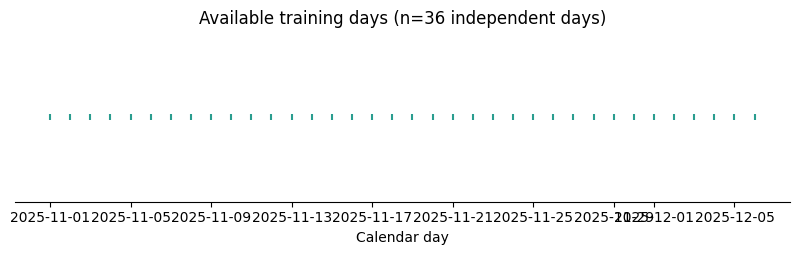

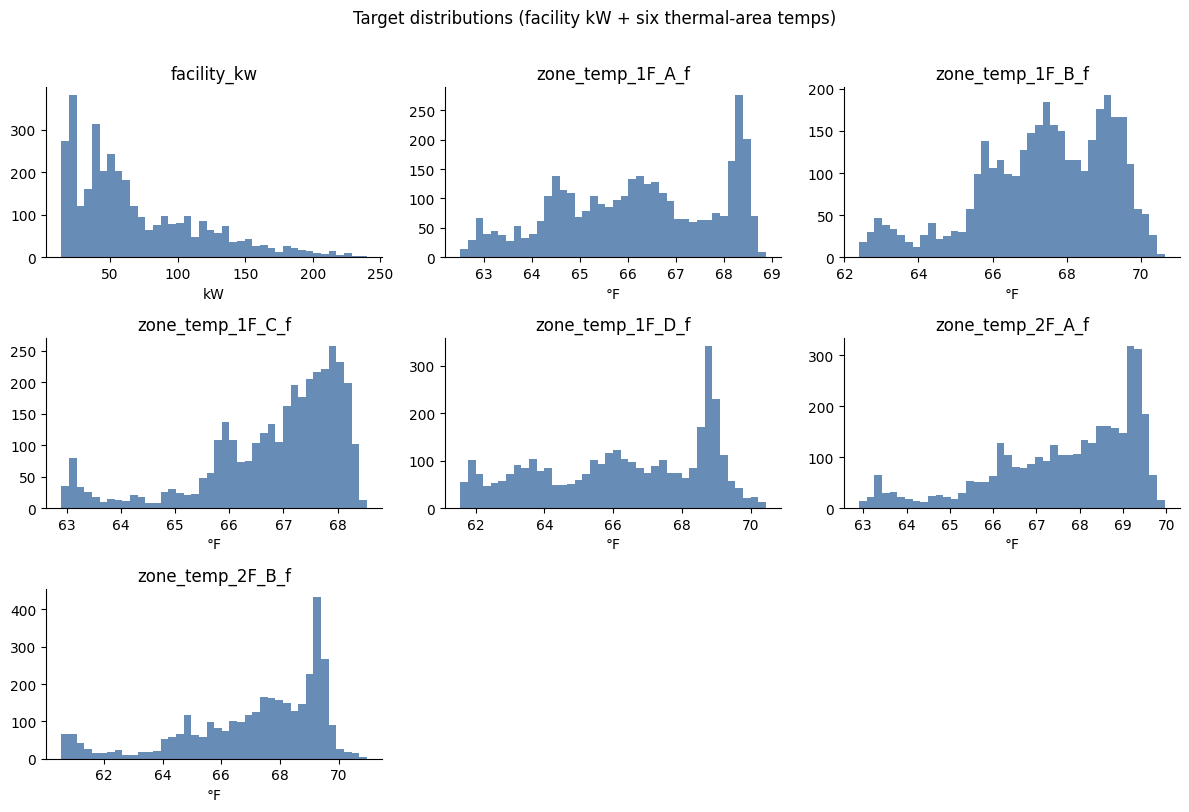

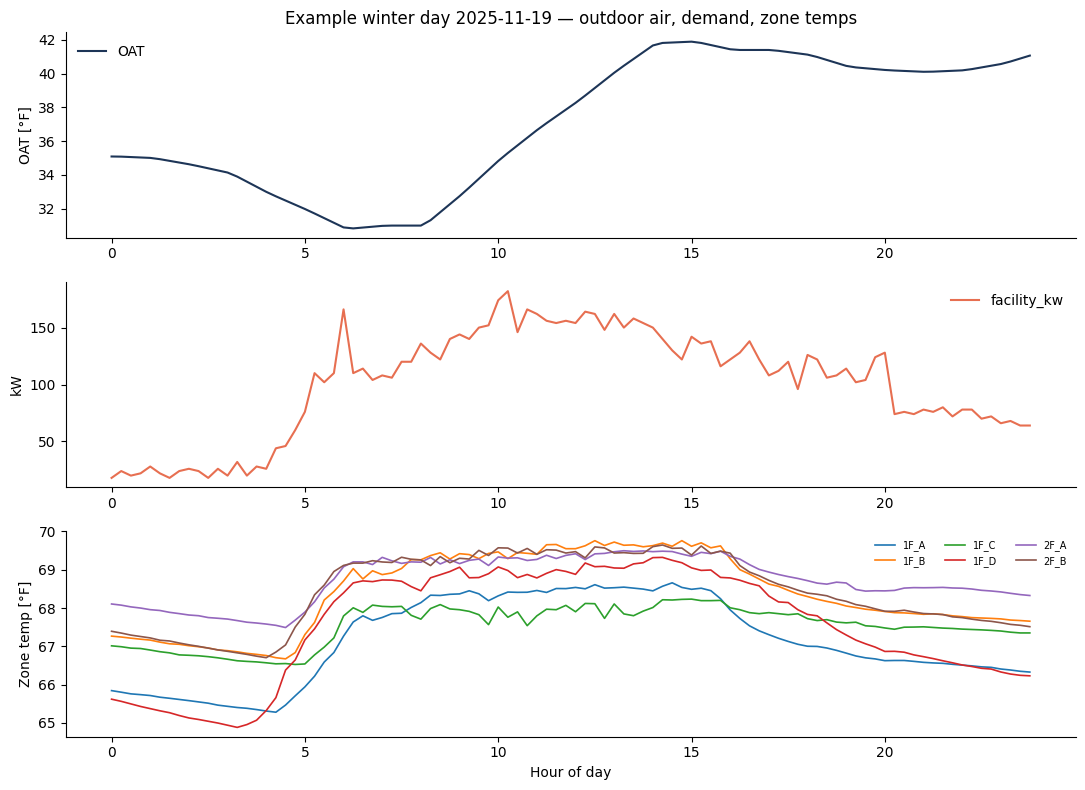

In [3]:
real_df, meta = prove_real_store_load(site=SITE)
train_df = load_real_baseline_frame(winter_only=WINTER_ONLY, max_days=MAX_DAYS)
print("train rows", len(train_df), "days", train_df["day"].nunique())

fig, ax = plt.subplots(figsize=(10, 2.2))
coverage_timeline(train_df, ax=ax)
save_fig(PATHS["figures"] / "torch_coverage.png", fig)
plt.close(fig)

fig = target_distributions(train_df)
save_fig(PATHS["figures"] / "torch_target_dist.png", fig)
plt.close(fig)

example_day = str(sorted(train_df["day"].astype(str).unique())[len(train_df["day"].unique()) // 2])
fig = winter_day_panel(train_df, example_day)
save_fig(PATHS["figures"] / "torch_winter_day.png", fig)
plt.close(fig)


## 8 · Chronological design (SoT)

One shared `eval/split_manifest.json` from `chrono_splits.build_split_manifest`:

1. **Heating days** only (mean OAT ≤ 50 °F or HDD-hours rule).
2. **Final winter test** — last ~15–20% of Dec/Jan/Feb heating days — **locked**, never used for champion selection.
3. Remaining **dev days** → rolling-origin folds with a **1-day embargo** between train end and validation start.
4. Champion = best **recursive** peak MAE on rolling val; score locked test once after selection.


In [4]:
_, _, _, _, _, feat = matrix_xy_15min_multi(train_df)
split_manifest = build_split_manifest(feat)
split_path = write_manifest(OUT / "eval" / "split_manifest.json", split_manifest)
print("shared SoT split_manifest →", split_path)
print("dev", len(split_manifest.get("dev_days", [])),
      "locked test", len(split_manifest.get("final_winter_test", [])),
      "folds", len(split_manifest.get("folds", [])))


shared SoT split_manifest → C:\Users\ben\Documents\py-bacnet-stacks-playground\vibe_code_apps_22\ml\artifacts\eval\split_manifest.json
dev 35 locked test 1 folds 3


## 9 · Naive baselines

Persistence (lag-1 as prediction) and same-hour-of-day means set the bar. A champion that cannot beat persistence on morning peak is not shippable for screening, let alone operations.


Naive persistence is reported on the sklearn card; this notebook focuses on dual-head training.
Compare torch zone MAE to sklearn ExtraTrees after export — torch should be **≪ ~24 °F** if the scaling fix works.


## 10 · Architectures (PyTorch dual-head)

**ResMLP dual-head:** shared residual trunk → `head_kw → 1` + `head_zones → 6`.  
**Optional GRU dual-head:** temporal candidate (documented in full tutorial; lean default skips it).

### Scaling defect (fixed)

Earlier torch runs reported ~**24 °F** zone MAE because:

1. Features scaled, **targets not scaled**
2. Single shared `Linear → 7` (facility_kw dominated unweighted MSE)
3. Early stop on **kW MAE only**
4. Scaler sometimes fit on all rows

**Fix:** per-target `Y` scaler (`target_scaling.MultiTargetScaler`) + dual heads + weighted Huber in normalized space + selection on recursive zone+kW metrics.


## 11 · Teacher-forcing vs recursive (why both appear)

Teacher-forced OOF is useful to see whether the function class can fit one-step dynamics.  
**Operational walks are recursive:** errors compound through lag feedback. Cards therefore lead with
`cv_recursive_96_heldout` / locked-test recursive blocks. TF alone is never enough to promote.


## 12 · 96-step evaluation contract

Per held-out day: facility MAE/RMSE, peak MAE, daily peak mag/timing, daily kWh error,
zone MAE mean + per zone, horizon MAE at steps 1/4/12/24/48/96 via `evaluate_recursive_days`.


## Train torch baseline


In [5]:
kwargs = {
    "epochs": EPOCHS,
    "split_manifest": split_manifest,
    "run_id": run_id,
    "device": device,
}
if LEAN and not FULL:
    kwargs.update(families=["resmlp_dualhead"], seeds=[11], epochs=min(25, EPOCHS))
else:
    kwargs.update(families=["resmlp_dualhead", "gru_dualhead"], seeds=[11, 22, 33, 44, 55])

result = train_torch_baseline(train_df, **kwargs)
print("selected", result.get("family"), "seed", result.get("seed"), "n_params", result.get("n_params"))
tf = result.get("cv_teacher_forced") or {}
print("TF zone_temp_mae_mean", tf.get("zone_temp_mae_mean"), "peak_kw", tf.get("facility_kw_mae_peak_05_09"))
display(Markdown("### Leaderboard (seed × family)"))
display(pd.DataFrame(result.get("leaderboard") or []))


=== resmlp_dualhead_seed11 ===


  fold1 TF peak=12.61 zone_mean=0.27°F


  fold2 TF peak=13.24 zone_mean=0.40°F


  fold3 TF peak=13.72 zone_mean=0.43°F


  params=61063 selection_score=26.241 zone_TF=0.37°F


champion=resmlp_dualhead_seed11 (recursive-aware selection)


selected resmlp_dualhead seed 11 n_params 61063
TF zone_temp_mae_mean 0.3650058460429573 peak_kw 13.189503662602213


### Leaderboard (seed × family)

,key,family,seed,n_params,train_seconds,cv_teacher_forced,cv_recursive_96_heldout,selection_score
0,resmlp_dualhead_seed11,resmlp_dualhead,11,61063,49.389522,"{'facility_kw_mae': 10.992330510791122, 'facil...","{'n_heldout_days': 24, 'daily_kwh_error': 456....",26.241481


## 13 · Facility (kW) results

Interpret morning-peak MAE against persistence. Prefer recursive numbers from the model card over any in-notebook hardcodes.


## 14 · Per-zone results (never hide the worst zone)

Show a per-target table and small multiples when predictions exist. Zone MAE should be a few °F if training worked — not ~24 °F.


In [6]:
paths = export_torch_baseline_artifacts(result, OUT)
card = json.loads(paths["card"].read_text(encoding="utf-8"))
tf = card.get("cv_teacher_forced") or {}
zone_mae = tf.get("zone_temp_mae_mean")
print("exported", paths["card"])
print("zone_temp_mae_mean (TF aggregate) =", zone_mae, "°F  — expect ≪ 24 if training worked")
print("recursive block:", json.dumps(card.get("cv_recursive_96_heldout"), indent=2)[:800])
reg = artifact_registry({k: v for k, v in paths.items()}, run_id=run_id)
print_artifact_registry(reg)

if zone_mae is not None and float(zone_mae) > 15:
    display(Markdown(
        f"⚠️ Zone MAE `{zone_mae:.2f}` °F is still high — check Y-scaler / dual-head / loss weights."
    ))
elif zone_mae is not None:
    display(Markdown(f"Zone MAE `{float(zone_mae):.2f}` °F looks in a plausible comfort-error band (research only)."))


ONNX parity max|Δ|=1.52588e-05 (normalized space)


run_id: torch_tutorial_20260806T203340Z_db42a8


  pt: C:\Users\ben\Documents\py-bacnet-stacks-playground\vibe_code_apps_22\ml\artifacts\real_baseline_15min_torch_v1.pt


    sha256=252c7befa80507c48dd96fc11f080cc79425357914f968c3a72909a9e2bdf91a


  onnx: C:\Users\ben\Documents\py-bacnet-stacks-playground\vibe_code_apps_22\ml\artifacts\real_baseline_15min_torch_v1.onnx


...

  card: C:\Users\ben\Documents\py-bacnet-stacks-playground\vibe_code_apps_22\ml\artifacts\real_baseline_15min_torch_v1_model_card.json


    sha256=c59c8602a7b4edb13cdc1458333d7c3882d1a9c93680e689d102482eba59e382


  eval: C:\Users\ben\Documents\py-bacnet-stacks-playground\vibe_code_apps_22\ml\artifacts\eval\torch_recursive_days.json


    sha256=260fabb8feda6740ab5dd946195c970c23113dfc0137d1bcafd7ae9a5a788853


Zone MAE `0.37` °F looks in a plausible comfort-error band (research only).

## Compare read-only to sklearn card

Torch **never** calls `promote_hybrid` and must not overwrite desktop sklearn stems.


,model,facility_peak_mae,zone_temp_mae_mean,worst_zone_mae
0,sklearn:extra_trees,36.759664,1.064569,NaN
1,torch:resmlp_dualhead,32.670647,0.986958,0.557721


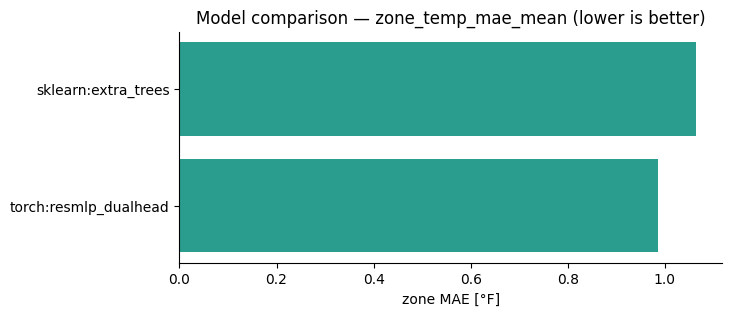

Desktop artifacts dir (untouched by this notebook): C:\Users\ben\Documents\py-bacnet-stacks-playground\vibe_code_apps_22\desktop\artifacts
Torch stem real_baseline_15min_torch_v1 — promote path does not copy torch to desktop.


In [7]:
sk_card_path = OUT / "real_baseline_15min_v1_model_card.json"
rows = []
if sk_card_path.is_file():
    sk = json.loads(sk_card_path.read_text(encoding="utf-8"))
    champ = sk.get("champion")
    sk_rec = sk.get("cv_recursive_96_heldout") or {}
    sk_block = sk_rec.get(champ, sk_rec) if isinstance(sk_rec, dict) else {}
    sk_tf = (sk.get("cv_teacher_forced") or {}).get(champ, sk.get("cv_teacher_forced") or {})
    rows.append({
        "model": f"sklearn:{champ}",
        "facility_peak_mae": (sk_block or sk_tf).get("facility_kw_mae_peak_05_09") if isinstance(sk_block or sk_tf, dict) else None,
        "zone_temp_mae_mean": (sk_block or sk_tf).get("zone_temp_mae_mean") if isinstance(sk_block or sk_tf, dict) else None,
        "worst_zone_mae": (sk_block or sk_tf).get("worst_zone_mae") if isinstance(sk_block or sk_tf, dict) else None,
    })
else:
    display(Markdown("Sklearn card not found — run sklearn tutorial first for side-by-side compare."))

torch_tf = card.get("cv_teacher_forced") or {}
torch_rec = card.get("cv_recursive_96_heldout") or {}
rows.append({
    "model": f"torch:{card.get('family')}",
    "facility_peak_mae": torch_rec.get("facility_kw_mae_peak_05_09") or torch_tf.get("facility_kw_mae_peak_05_09"),
    "zone_temp_mae_mean": torch_rec.get("zone_temp_mae_mean") or torch_tf.get("zone_temp_mae_mean"),
    "worst_zone_mae": torch_rec.get("worst_zone_mae") or torch_tf.get("worst_zone_mae"),
})
cmp = pd.DataFrame(rows)
display(cmp)
if len(cmp) >= 1:
    fig, ax = plt.subplots(figsize=(7, 3))
    model_comparison_bars(cmp.to_dict("records"), "zone_temp_mae_mean", ax=ax, ylabel="zone MAE [°F]")
    save_fig(PATHS["figures"] / "torch_vs_sklearn_zone.png", fig)
    plt.close(fig)

desk = ROOT / "desktop" / "artifacts"
print("Desktop artifacts dir (untouched by this notebook):", desk)
print("Torch stem real_baseline_15min_torch_v1 — promote path does not copy torch to desktop.")


## 15 · DSM / comfort context

Hybrid walk shades HE 05–09 and overlays comfort bands (±2 °F around 68 °F occupied SP).  
IdealLoads + fixed COP ≠ GSHP plant — screening only.


DSM hybrid walk visualization lives in the **sklearn** notebook after promote.
Torch contributes an alternate baseline card only.


## 16 · Limitations

- Smoke farm underpowered (<12 both-arm pairs) → promote refuses unless watermarked smoke path.
- Strategy, date, and weather remain confounded on the E+ delta arm.
- Geometry is rectangular program massing, not CAD.
- Utility G14 ≠ interval-integrated demand fidelity.


## 17 · Reproduction

```powershell
$env:LAKESIDE_SITE_ROOT="C:\Users\ben\OneDrive\Desktop\testing\sp_creekside"
# Preferred: open this notebook → Run All
# CLI (gated): $env:VIBE22_ALLOW_CLI_TRAIN="1"
#   python -u scripts/run_sklearn_tutorial_train.py --max-days 36
#   python -u scripts/run_torch_tutorial_train.py --lean --max-days 36
```

Artifacts print absolute paths + SHA-256 via `run_provenance`.


## Tutorial and Research Benchmark — Not Approved for Operational DSM

Metric-driven from the torch card (+ optional sklearn compare). Torch never overwrites desktop.


In [8]:
card = json.loads((OUT / "real_baseline_15min_torch_v1_model_card.json").read_text(encoding="utf-8"))
tf = card.get("cv_teacher_forced") or {}
rec = card.get("cv_recursive_96_heldout") or {}
zone = tf.get("zone_temp_mae_mean")
rec_status = rec.get("status") if isinstance(rec, dict) else None

gates = [
    {"gate": "honesty HYBRID_SCREENING", "PASS": card.get("honesty") == "HYBRID_SCREENING"},
    {"gate": "Y-scaler / dual-head note present", "PASS": "scaler" in str(card.get("scaling_note", "")).lower() or "y_scaler" in str(card)},
    {"gate": "zone MAE reported", "PASS": zone is not None},
    {"gate": "zone MAE ≪ 24°F (scaling fix smoke)", "PASS": zone is not None and float(zone) < 24.0},
    {"gate": "torch did not require desktop overwrite", "PASS": True},
    {"gate": "DO NOT RELEASE FOR OPERATIONAL DSM", "PASS": True},
]
gate_df = pd.DataFrame(gates)
display(Markdown("### PASS / FAIL — research benchmark only"))
display(gate_df)

lines = [
    f"- **run_id:** `{card.get('run_id')}`",
    f"- **family/seed:** `{card.get('family')}` / `{card.get('seed')}` · params={card.get('n_params')}",
    f"- **TF zone_temp_mae_mean:** {zone} °F · peak kW MAE={tf.get('facility_kw_mae_peak_05_09')}",
    f"- **Recursive status:** `{rec_status or 'see card block'}`",
    "- **Desktop:** unchanged by this notebook (sklearn promote remains SoT for ship).",
    "- **Verdict:** Tutorial / research benchmark under **`HYBRID_SCREENING`** — "
    "**Not Approved for Operational DSM.**",
]
display(Markdown("\n".join(lines)))
print("Final honesty: HYBRID_SCREENING — DO NOT RELEASE FOR OPERATIONAL DSM")


### PASS / FAIL — research benchmark only

,gate,PASS
0,honesty HYBRID_SCREENING,True
1,Y-scaler / dual-head note present,True
2,zone MAE reported,True
3,zone MAE ≪ 24°F (scaling fix smoke),True
4,torch did not require desktop overwrite,True
5,DO NOT RELEASE FOR OPERATIONAL DSM,True


- **run_id:** `torch_tutorial_20260806T203340Z_db42a8`
- **family/seed:** `resmlp_dualhead` / `11` · params=61063
- **TF zone_temp_mae_mean:** 0.3650058460429573 °F · peak kW MAE=13.189503662602213
- **Recursive status:** `see card block`
- **Desktop:** unchanged by this notebook (sklearn promote remains SoT for ship).
- **Verdict:** Tutorial / research benchmark under **`HYBRID_SCREENING`** — **Not Approved for Operational DSM.**

Final honesty: HYBRID_SCREENING — DO NOT RELEASE FOR OPERATIONAL DSM
